# Notebook 10 — Target Variable Analysis
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Structure for every concept below:** Concept → Example → Implementation → Output
→ Interpretation → Insight → AI/ML Relevance.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns).

**Target variable:** `Churn` (Yes / No) — confirmed a **binary classification** problem
back in Notebook 1. This notebook follows the sprint brief's classification branch
(Class Distribution, Class Counts, Class Percentages, Class Imbalance) rather than the
regression branch, since this dataset has no continuous target to predict. The regression
branch is still summarized briefly at the end, for completeness, explaining what it would
involve for a dataset that had one.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4.5)

df = pd.read_csv("telco_churn.csv")
print(f"Dataset ready: {df.shape[0]:,} rows")
print(f"Target variable: Churn — {df['Churn'].dtype} dtype, {df['Churn'].nunique()} unique values")


Dataset ready: 7,043 rows
Target variable: Churn — str dtype, 2 unique values


---
## 1. Class Distribution

### Concept
Class distribution describes how the target variable's possible outcomes are spread
across the dataset — the overall shape of "how many of each class exist," typically shown
visually before looking at exact numbers.

### Example
**AI/ML use case:** Before writing a single line of model code, plotting the target's
class distribution is the standard first step of any classification project — it sets
expectations for every metric interpreted afterward.

### Implementation


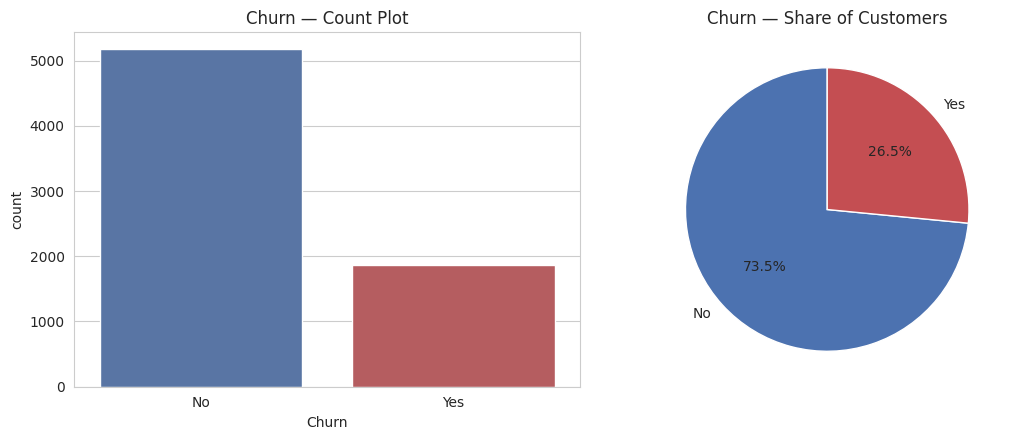

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.countplot(data=df, x='Churn', order=['No', 'Yes'], hue='Churn',
              palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False, ax=axes[0])
axes[0].set_title('Churn — Count Plot')

churn_counts = df['Churn'].value_counts().reindex(['No', 'Yes'])
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[1].set_title('Churn — Share of Customers')

plt.tight_layout()
plt.show()


### Output
Two views of the same distribution: a count plot showing raw bar heights, and a pie chart
showing the same split as percentages.

### Interpretation
Both charts show the same story from two angles — a clearly unequal but not extreme
split, with the "No" (stayed) class visibly larger than the "Yes" (churned) class in both
the bar heights and the pie slice sizes.

### Insight
Choosing a pie chart here is deliberate and appropriate (Sprint 2, Notebook 13's
guidance) specifically because there are only 2 categories — pie charts become harder to
read with more categories, but for a binary target they communicate "roughly a quarter
churned" more immediately than a bar chart's y-axis would.

### AI/ML Relevance
This is the single most important chart to produce before starting any classification
project — it's the first, fastest signal of whether the target is balanced or not, which
shapes nearly every modeling decision that follows.


---
## 2. Class Counts

### Concept
Class counts are the exact raw number of observations in each category — the precise
numbers underlying Topic 1's visual impression.

### Example
**Business example:** "About a quarter of customers churn" (Topic 1's visual impression)
is useful, but "1,869 customers churned out of 7,043" is the exact number a business team
would use to estimate revenue impact.

### Implementation


In [3]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)


Churn
No     5174
Yes    1869
Name: count, dtype: int64


### Output
`No`: 5,174 customers. `Yes`: 1,869 customers.

### Interpretation
The exact counts confirm the visual impression from Topic 1 with precision — there are
nearly 3 times as many non-churned as churned customers in raw terms.

### Insight
1,869 is still a substantial number of examples for a model to learn the minority
("churned") class from — not so few that the class would be considered severely
data-starved (a dataset with only a few dozen minority examples would be a much bigger
concern).

### AI/ML Relevance
Raw counts (not just percentages) matter for a practical reason: they determine how many
minority-class examples will actually land in a train/test split — with 1,869 total,
even an 80/20 split still leaves both the training and test sets with several hundred
churned examples to learn from and evaluate against.


---
## 3. Class Percentages

### Concept
Class percentages express the same counts as proportions of the whole — the standard way
to communicate class balance independent of the dataset's absolute size.

### Example
**AI/ML use case:** "26.5% churn rate" is directly comparable to another company's churn
dataset with a different total customer count, whereas raw counts alone wouldn't be.

### Implementation


In [4]:
churn_pct = (df['Churn'].value_counts(normalize=True) * 100).round(2)
print(churn_pct)


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### Output
`No`: 73.46%. `Yes`: 26.54%.

### Interpretation
Restating Topic 2's counts as percentages makes the imbalance ratio immediately legible
without needing to do the division mentally — roughly 3-in-4 stayed, 1-in-4 churned.

### Insight
This 73.46%/26.54% split will resurface directly in Topic 4 as the exact numeric
definition of how imbalanced this target is — percentages are the natural units for that
classification.

### AI/ML Relevance
This percentage is exactly what a "majority-class baseline" model would achieve on
accuracy alone (formally computed and discussed in Topic 4) — a number every actual
trained model's accuracy must be compared against, not treated as a good score in
isolation.


---
## 4. Class Imbalance

### Concept
(Recap from Sprint 2, Notebook 1) Class imbalance means one class substantially
outnumbers another — the degree of imbalance determines whether special evaluation
metrics or resampling techniques are needed, ranging from mild (this dataset) to severe
(e.g., 1% fraud rate datasets).

### Example
**AI/ML use case:** A model that always predicts "No churn" for every single customer
would still score a deceptively high accuracy, purely because the majority class is so
much larger — exactly the "accuracy paradox" first introduced in Sprint 2, Notebook 1,
now demonstrated on this dataset's real numbers.

### Implementation


In [5]:
imbalance_ratio = churn_counts.max() / churn_counts.min()
majority_baseline_accuracy = churn_counts.max() / len(df) * 100

print(f"Imbalance ratio (majority : minority): {imbalance_ratio:.2f} : 1")
print(f"A model that ALWAYS predicts 'No churn' would score: {majority_baseline_accuracy:.2f}% accuracy")
print(f"...despite catching ZERO of the {churn_counts['Yes']:,} customers who actually churned.")


Imbalance ratio (majority : minority): 2.77 : 1
A model that ALWAYS predicts 'No churn' would score: 73.46% accuracy
...despite catching ZERO of the 1,869 customers who actually churned.


### Output
Imbalance ratio: 2.77 : 1. A "predict everyone stays" model would score 73.46% accuracy
while correctly identifying 0 of the 1,869 customers who actually churned.

### Interpretation
This is a moderate, not severe, imbalance (2.77:1) — nowhere near the extreme ratios seen
in fraud or rare-disease detection (often 100:1 or worse), but still large enough that
accuracy alone would be a genuinely misleading metric, as the "always predict No" example
starkly demonstrates.

### Insight
Because this is only moderate imbalance, aggressive techniques like SMOTE oversampling or
severe class-weighting are likely unnecessary — but precision, recall, and F1-score
(Sprint 2, Notebook 2) are still essential for honestly evaluating any model built on
this target, rather than accuracy alone.

### AI/ML Relevance
This finding directly determines the evaluation plan for the eventual churn model: report
precision/recall/F1 (and likely ROC-AUC) rather than leading with accuracy, and consider
`class_weight='balanced'` as a lightweight first response to the imbalance rather than
jumping straight to resampling.


---
## 5. Why Understanding the Target Variable Matters Before Machine Learning

### Concept
The target variable defines the entire problem a model is trying to solve — its type
(classification vs. regression), its balance, and its distribution shape all directly
determine which algorithms, evaluation metrics, and preprocessing choices are even valid
options.

### Example
**Business example:** Building a churn model without first checking that `Churn` is
imbalanced (Topic 4) could lead a team to proudly report "91% accuracy" on a model that's
functionally useless for its actual business purpose — catching customers before they
leave.

### Implementation


In [6]:
print("Summary of what THIS notebook's target analysis determines for the modeling stage:")
print(f"  Problem type      : Binary classification (2 classes: {list(df['Churn'].unique())})")
print(f"  Class balance     : Moderate imbalance ({imbalance_ratio:.2f}:1)")
print(f"  Naive baseline    : {majority_baseline_accuracy:.1f}% accuracy (NOT a good model, just the imbalance)")
print(f"  Metric implication: Use precision, recall, F1, and/or ROC-AUC — not accuracy alone")
print(f"  Split implication : Use STRATIFIED train/test split to preserve the {majority_baseline_accuracy:.1f}/{100-majority_baseline_accuracy:.1f} ratio in both sets")


Summary of what THIS notebook's target analysis determines for the modeling stage:
  Problem type      : Binary classification (2 classes: ['No', 'Yes'])
  Class balance     : Moderate imbalance (2.77:1)
  Naive baseline    : 73.5% accuracy (NOT a good model, just the imbalance)
  Metric implication: Use precision, recall, F1, and/or ROC-AUC — not accuracy alone
  Split implication : Use STRATIFIED train/test split to preserve the 73.5/26.5 ratio in both sets


### Output
A consolidated summary connecting every finding in this notebook to a specific downstream
modeling decision.

### Interpretation
Every single line in this summary is a decision that could go wrong if the target
variable analysis in this notebook were skipped — the problem type determines which
algorithms even apply, the imbalance determines the evaluation metric, and the exact
ratio determines how the train/test split itself must be constructed.

### Insight
This notebook's real contribution isn't just describing `Churn` in isolation — it's
translating that description into concrete guardrails for the next sprint, so the
modeling team doesn't have to rediscover "accuracy is misleading here" the hard way after
already training and reporting on a model.

### AI/ML Relevance
This is precisely why target variable analysis gets its own dedicated notebook in this
sprint, separate from the general univariate analysis (Notebook 4) — the target isn't
just another variable, it's the variable every modeling decision downstream is built
around.


---
## 6. If the Target Were Continuous — The Regression Branch (Not Applicable Here)

### Concept
The sprint brief also specifies a regression analysis branch — Target Distribution, Mean,
Median, Variance, Standard Deviation, Skewness, and Outliers — for datasets where the
target is a continuous number rather than a category. `Churn` is categorical, so this
branch doesn't apply here, but it's worth explicitly addressing rather than silently
skipping.

### Example
**AI/ML use case:** If this dataset's business question had instead been "predict a
customer's `MonthlyCharges`" or "predict total lifetime `TotalCharges`," that continuous
column would BECOME the target, and this regression branch would apply directly — using
exactly the techniques already demonstrated on these two columns in Notebooks 4 and 8.

### Implementation


In [7]:
print("This dataset's target (Churn) is categorical, so the regression branch is not applicable.")
print("\nFor illustration only, here is what the regression branch WOULD look like if")
print("'MonthlyCharges' were treated as a target instead of a feature (already computed in Notebooks 4 & 8):")
print(f"  Mean               : {df['MonthlyCharges'].mean():.2f}")
print(f"  Median             : {df['MonthlyCharges'].median():.2f}")
print(f"  Variance           : {df['MonthlyCharges'].var():.2f}")
print(f"  Standard Deviation : {df['MonthlyCharges'].std():.2f}")


This dataset's target (Churn) is categorical, so the regression branch is not applicable.

For illustration only, here is what the regression branch WOULD look like if
'MonthlyCharges' were treated as a target instead of a feature (already computed in Notebooks 4 & 8):
  Mean               : 64.76
  Median             : 70.35
  Variance           : 905.41
  Standard Deviation : 30.09


### Output
A brief illustrative reuse of `MonthlyCharges`'s already-known statistics (Notebook 4),
framed as "what if this were the target," rather than fabricated regression output for a
target that doesn't exist in this dataset.

### Interpretation
The regression branch's required statistics (mean, median, variance, std, skewness,
outliers) are exactly the univariate techniques from Notebook 4 and the outlier detection
from Notebook 7 — target variable analysis for regression isn't a different toolkit, it's
the same toolkit specifically applied to whichever single column is designated the target.

### Insight
Correctly identifying that this is a classification problem (Notebook 1) was the
prerequisite that made this whole notebook's approach (Topics 1-4) the right one to take
— getting that initial classification vs. regression judgment wrong would have led this
entire notebook down the wrong analytical path.

### AI/ML Relevance
This distinction — confirming problem type before choosing an analysis approach — is
worth stating explicitly because it's easy to skip when a dataset's target is obviously
categorical (like this one), but far more consequential to get right on a less obvious
dataset, such as Notebook 14's upcoming EDA Mini Challenge on an unfamiliar dataset.


---
## Summary

| Concept | Finding for THIS dataset |
|---|---|
| Problem Type | Binary classification (`Churn`: Yes/No) |
| Class Distribution | Visibly unequal but not extreme — confirmed via count plot and pie chart |
| Class Counts | No: 5,174. Yes: 1,869 |
| Class Percentages | No: 73.46%. Yes: 26.54% |
| Class Imbalance | Moderate, 2.77:1 ratio — naive "always No" baseline scores 73.46% accuracy while catching 0 churners |
| Regression Branch | Not applicable (target is categorical); illustrated conceptually using `MonthlyCharges` |

**Key takeaway carried forward:** Any model built on this target must be evaluated with
precision/recall/F1 (or ROC-AUC), must use a stratified train/test split, and should not
be judged by accuracy alone — this is now a documented, non-negotiable requirement for
the next sprint's modeling work, not just a passing observation.

**Next notebook:** `11_EDA_Visualization.ipynb` — a dedicated round-up of meaningful
Matplotlib/Seaborn visualizations across the dataset, each justified by why it was chosen
and what insight it reveals.
